## 사전 학습을 위한 데이터세트 구성

BERT 모델은 사전학습과 미세조정(Fine-Tuning)이 확실하게 나눠지는 대표적인 모델입니다.  
미세조정은 자연어 Task에 따라 다양하게 진행 될 수 있지만, 사전 학습은 대부분 NSP 학습과 MLM 학습으로 진행이 됩니다.   

해당 예시에서는 [AIHUB](https://www.aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&dataSetSn=86) 한국어 감성 대화 말뭉치를 부분적으로 활용하여 질의->응답 으로 NSP와 MLM 사전 학습을 동시 진행해봅니다.

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving train.csv to train.csv


In [ ]:
import torch
from torch import nn
import copy
from torch.utils.data import Dataset, DataLoader, random_split
import sentencepiece as spm
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv(f'./train.csv')
df[['HS01','SS01']]

,HS01,SS01
0,일은 왜 해도 해도 끝이 없을까? 화가 난다.,많이 힘드시겠어요. 주위에 의논할 상대가 있나요?
1,이번 달에 또 급여가 깎였어! 물가는 오르는데 월급만 자꾸 깎이니까 너무 화가 나.,급여가 줄어 속상하시겠어요. 월급이 줄어든 것을 어떻게 보완하실 건가요?
2,회사에 신입이 들어왔는데 말투가 거슬려. 그런 애를 매일 봐야 한다고 생각하니까 스...,회사 동료 때문에 스트레스를 많이 받는 것 같아요. 문제 해결을 위해 어떤 노력을 ...
3,직장에서 막내라는 이유로 나에게만 온갖 심부름을 시켜. 일도 많은 데 정말 분하고 ...,관련 없는 심부름을 모두 하게 되어서 노여우시군요. 어떤 것이 상황을 나아질 수 있...
4,얼마 전 입사한 신입사원이 나를 무시하는 것 같아서 너무 화가 나.,무시하는 것 같은 태도에 화가 나셨군요. 상대방의 어떤 행동이 그런 감정을 유발하는...
...,...,...
51623,나이가 먹고 이제 돈도 못 벌어 오니까 어떻게 살아가야 할지 막막해. 능력도 없고.,경제적인 문제 때문에 막막하시군요. 마음이 편치 않으시겠어요.
51624,몸이 많이 약해졌나 봐. 이제 전과 같이 일하지 못할 것 같아 너무 짜증 나.,건강에 대한 어려움 때문에 기분이 좋지 않으시군요. 속상하시겠어요.
51625,이제 어떻게 해야 할지 모르겠어. 남편도 그렇고 노후 준비도 안 되어서 미래가 걱정돼.,노후 준비에 대한 어려움 때문에 걱정이 많으시겠어요.
51626,몇십 년을 함께 살았던 남편과 이혼했어. 그동안의 세월에 배신감을 느끼고 너무 화가 나.,가족과의 문제 때문에 속상하시겠어요.


### NSP 학습을 위한 두문장 토큰

BERT 사전학습에 있어서 먼저 NSP 학습이 가능하게 하기 위해 2개의 문장을 연결하여 적절하게 연결된 문장과 비적절하게 연결된 문장을 이진 분류 할 수 있게 구성해 줍니다.  

이때 데이터세트에서 만들 최종 토큰은 다음과 같습니다.

    시작토큰[CLS] + 문장1 토큰+ 구분토큰[SEP] + 문장2 토큰 + 구분(종료)토큰[SEP]

    예시: [CLS], 오늘, 수업, 뭐지, [SEP], 자연어, 분석, 수업, [SEP]

이렇게 토큰이 BERT 입력되면 [CLS] 토큰은 모든 토큰과의 연관성이 포함되기 때문에 [CLS] 토큰으로 문장의 연결이 적절한지 분류가 가능해집니다.  

<center><img src="https://drive.google.com/uc?export=view&id=1N1r3JPdmIxXK6QxJASuN_ABpWkgfjm0I" width="400"/></center>

예시에서는 `sentencepiece` 토큰화를 사용하므로 기존에 있는 스페셜 토큰인 `bos`를 `CLS`로 `eos`를 `SEP`으로 활용합니다.




In [ ]:
# 전체 코드의 목적과 흐름:
# 이 코드는 BERT 모델의 사전학습(Pre-training)을 위해 데이터를 준비하는 과정입니다.
# BERT 모델은 두 가지 주요 사전학습 과제를 수행합니다:
# 1. MLM(Masked Language Modeling): 일부 토큰을 가려서 원래 토큰을 예측
# 2. NSP(Next Sentence Prediction): 두 문장이 연속적인지 여부를 예측
# 이 코드는 이러한 학습을 위해 텍스트 데이터를 전처리하고 BPE 토크나이저를 학습시킵니다.

import torch
from torch import nn  # 신경망 모듈 (레이어, 활성화 함수, 손실 함수 등)
import copy  # 객체 복사를 위한 모듈 (모델 가중치 복사시 사용)
from torch.utils.data import Dataset, DataLoader, random_split  # 데이터셋 관리 및 미니배치 처리
import sentencepiece as spm  # 구글에서 개발한 서브워드 토크나이저 라이브러리
import pandas as pd  # 데이터 처리와 분석을 위한 라이브러리 (CSV 파일 읽기/쓰기)
import numpy as np  # 수치 계산을 위한 라이브러리 (배열 연산, 수학 함수)

# CSV 파일에서 데이터 읽어오기
# './train.csv' 파일을 pandas DataFrame으로 로드합니다.
# 이 파일에는 대화 데이터가 포함되어 있으며, 'HS01'과 'SS01' 컬럼을 사용합니다.
df = pd.read_csv(f'./train.csv')

# DataFrame에서 'HS01'(질문/문장1)과 'SS01'(응답/문장2) 컬럼만 선택하여 확인
# 이 두 컬럼은 NSP 학습을 위한 문장 쌍으로 사용될 것입니다.
df[['HS01','SS01']]

# BPE(Byte Pair Encoding) 토크나이저 학습을 위한 텍스트 전처리
# BPE는 자주 등장하는 문자 쌍을 점차적으로 하나의 토큰으로 병합하는 압축 알고리즘입니다.
import os  # 운영체제 인터페이스 (파일 경로, 디렉토리 생성 등)
import re  # 정규 표현식 (텍스트 패턴匹配 및 처리)

# 'train.txt' 파일을 쓰기 모드로 열어 전처리된 텍스트 데이터를 저장합니다.
# UTF-8 인코딩으로 한국어 텍스트를 올바르게 처리합니다.
with open('train.txt', 'w', encoding='utf-8') as f:

    # DataFrame의 'HS01' 컬럼에 있는 모든 텍스트에 대해 반복 처리
    for text in df['HS01']:
        text = str(text)  # NaN이나 None 값 방지를 위해 문자열로 변환

        # 정규 표현식을 사용한 텍스트 정제 과정:
        # [^\w\s] 패턴: 단어 문자(\w: [a-zA-Z0-9_])와 공백(\s)을 제외한 모든 문자를 찾아 제거
        # ^은 부정, \w는 단어 문자, \s는 공백 문자를 의미
        # 따라서 특수문자, 구두점 등을 제거하는 역할
        text = re.sub(r'[^\w\s]', '', text)

        # 줄바꿈(\n)과 탭(\t) 문자를 일반 공백으로 대체
        # 이러한 화이트스페이스 문자를 통일하여 토크나이징 일관성 확보
        text = re.sub(r'[\n\t]', ' ', text)

        # 연속된 공백 문자(스페이스, 탭 등)를 단일 공백으로 압축
        # \s+는 하나 이상의 공백 문자를 의미
        text = re.sub(r'\s+', ' ', text)

        # 문자열 양끝의 공백 문자 제거 (앞뒤 불필요한 공백 정리)
        text = text.strip()

        # 전처리된 텍스트를 파일에 쓰기 (각 문장을 개행으로 구분)
        try:
            f.write(text + '\n')  # 문장 끝에 줄바꿈 추가하여 기록
        except:
            pass  # 쓰기 도중 오류 발생시 무시하고 계속 진행

# BPE 모델 파일을 저장할 디렉토리 생성
# exist_ok=True: 이미 디렉토리가 존재하면 오류를 발생시키지 않음
os.makedirs('./bpe', exist_ok=True)

# entencePiece 모델 학습 (상세 설정)
# BERT의 특수 토큰 요구사항을 고려하여 더 정교하게 모델을 학습합니다.
spm.SentencePieceTrainer.train(
    input='train.txt',               # 학습 데이터 사용
    model_prefix='./bpe/spm_krsent', # 모델 이름
    vocab_size=4000,                 # vocabulary 크기 (4000개 토큰)

    # BERT에서 사용하는 특수 토큰들에 대한 ID 명시적 지정:
    bos_id=1,   # Beginning Of Sentence (문장 시작) 토큰 ID - BERT의 [CLS] 토큰으로 사용될 것
    eos_id=2,   # End Of Sentence (문장 끝) 토큰 ID - BERT의 [SEP] 토큰으로 사용될 것
    unk_id=3,   # Unknown Token (알 수 없는 토큰) ID - vocabulary에 없는 토큰 처리용
    pad_id=0    # Padding Token (패딩 토큰) ID - 배치 처리시 길이를 맞추기 위한 패딩
)

# BPE 토크나이저의 작동 원리:
# 1. 초기: 모든 단어를 문자 단위로 분해 (e.g., "learning" -> "l", "e", "a", "r", "n", "i", "n", "g")
# 2. 반복: 가장 빈번하게共現하는 바이트 쌍을 하나의 토큰으로 병합
# 3. 결과: 자주 쓰이는 서브워드(Subword)들로 구성된 vocabulary 생성

# SentencePiece의 장점:
# - 언어 독립적: 한국어, 영어, 중국어 등 다양한 언어 처리 가능
# - 공백 보존: 공백 문자도 일반 토큰처럼 처리하여 전처리 부담 감소
# - 손실 없는 복원: 토큰 시퀀스를 원본 텍스트로 완벽 복원 가능

# 이렇게 학습된 토크나이저는 다음 단계에서:
# - 텍스트를 토큰 ID 시퀀스로 변환
# - BERT 입력 형식([CLS] 문장1 [SEP] 문장2 [SEP]) 구성
# - MLM과 NSP 학습을 위한 데이터셋 생성에 사용됨

# 주의사항:
# - 한국어의 경우 띄어쓰기가 중요한 의미를 가지므로 공백 처리에 주의
# - Vocabulary 크기는 메모리 사용과 모델 성능 사이의 trade-off
# - 특수 토큰 ID 설정은 BERT 모델 구현과 일치해야 함

In [ ]:
"""
현재 단계: BERT의 사전학습을 위한 데이터셋 구축 - NSP(Next Sentence Prediction) 학습 데이터 준비

전체 목표:
BERT 모델은 두 가지 주요 사전학습 태스크를 통해 언어 이해 능력을 획득합니다:
1. MLM (Masked Language Modeling): 일부 단어를 가리고 원래 단어 예측 (단어 수준 이해)
2. NSP (Next Sentence Prediction): 두 문장의 연속성 판별 (문장 수준 이해)

이 코드에서는 특히 NSP 학습을 위한 데이터를 구성합니다.

NSP의 중요성:
- 문장 간의 논리적 관계 이해
- 대화 흐름 파악
- 문서 구조 이해 능력 향상
- QA, 자연어 추론 등 다운스트림 태스크에 필수적
"""

class SPDataSet(Dataset):
    """
    BERT 사전학습을 위한 커스텀 데이터셋 클래스
    PyTorch의 Dataset 클래스를 상속받아 구현
    """

    def __init__(self, sp, max_len):
        """
        데이터셋 초기화 메서드

        Args:
            sp: 학습된 SentencePiece 토크나이저 객체
                - 텍스트를 서브워드 토큰으로 분해하고 ID로 변환하는 역할
            max_len: 최대 시퀀스 길이 (BERT 입력의 고정 길이)
                - 모든 문장을 이 길이로 통일 (패딩 또는 트림)
        """
        self.max_len = max_len  # 모델 입력의 고정 길이 저장 (예: 60토큰)
        self.df = pd.read_csv(f'./train.csv')  # 원본 CSV 파일 로드
        self.sp = sp  # SentencePiece 토크나이저 객체 저장

        # NSP 학습을 위한 문장 쌍을 저장할 리스트
        # 각 요소는 (문장1, 문장2, 라벨) 형태의 튜플
        self.pairs = []

        """
        [NSP 양성 샘플 생성 - 라벨 1]
        실제 대화 데이터에서의 연속적인 문장 쌍을 양성 샘플로 사용
        데이터셋의 각 행은 실제 대화에서의 질문-응답 쌍을 포함
        """
        # 데이터프레임의 각 행을 순회하며 실제 문장 쌍 수집
        for _, item in df.iterrows():  # iterrows(): (인덱스, 행데이터) 반복자
            sent1 = item['HS01']  # Human Sentence 01 - 질문/발화 문장
            sent2 = item['SS01']  # System Sentence 01 - 응답/답변 문장
            # 실제로 연속적인 대화 흐름이므로 라벨 1(양성)으로 설정
            self.pairs.append((sent1, sent2, 1))

        """
        [NSP 음성 샘플 생성 - 라벨 0]
        무작위로 조합된 문장 쌍을 음성 샘플로 사용
        모델이 비연속적인 문장 관계를 구분하도록 학습시키기 위함
        """
        n_lines = len(df)  # 전체 데이터 행 수 계산

        # 0부터 n_lines-1까지의 범위에서 n_lines-1개의 무작위 인덱스 생성
        # size=(n_lines-1,): 1차원 배열로 n_lines-1개 생성
        rand_indices = np.random.randint(0, n_lines, size=(n_lines-1,))

        # 무작위 인덱스를 사용하여 비연속 문장 쌍 생성
        for i, rand_idx in enumerate(rand_indices):
            # 같은 인덱스인 경우 스킵 (실제 쌍과 중복 방지)
            if i == rand_idx:
                continue

            sent1 = df.iloc[i]['HS01']  # i번째 행의 질문 문장
            sent2 = df.iloc[rand_idx]['SS01']  # 무작위 다른 행의 응답 문장
            # 실제로 연속적이지 않은 무작위 쌍이므로 라벨 0(음성)으로 설정
            self.pairs.append((sent1, sent2, 0))

        """
        [데이터셋 구성 확인]
        생성된 문장 쌍의 앞뒤 10개를 출력하여 데이터 구성을 확인
        """
        print("데이터셋 앞쪽 10개 샘플 (실제 연결 + 무작위 연결 혼합):")
        print(self.pairs[:10])
        print("데이터셋 뒤쪽 10개 샘플:")
        print(self.pairs[-10:])

        """
        데이터셋 크기 정보:
        - 총 샘플 수: len(df) * 2 - 1 (양성 n개 + 음성 n-1개)
        - 양성:음성 비율이 거의 1:1에 가까움 (균형 잡힌 데이터셋)
        """

    def zero_pad(self, tok):
        """
        시퀀스 길이를 통일하기 위한 제로 패딩 함수

        BERT 모델은 고정 길이 입력을 요구하므로, 모든 시퀀스를 동일한 길이로 맞춤
        패딩(Padding): 짧은 시퀀스의 뒤쪽을 0으로 채움
        트림(Trimming): 긴 시퀀스의 앞쪽을 자름

        Args:
            tok: 토큰 ID로 구성된 리스트 또는 배열 (예: [1, 45, 23, 2])

        Returns:
            max_len 길이로 패딩된 numpy 배열
        """
        if len(tok) >= self.max_len:
            # 시퀀스가 최대 길이보다 길거나 같으면 앞부분을 자름
            return tok[:self.max_len]
        else:
            # 시퀀스가 짧으면 제로 패딩 적용
            # zeros(max_len): max_len 크기의 0으로 채워진 배열 생성
            padding = np.zeros(self.max_len)
            # 앞부분에 실제 토큰 복사
            padding[:len(tok)] = tok
            return padding
            # 예: tok=[1,2,3], max_len=5 → return [1,2,3,0,0]

    def __getitem__(self, i):
        """
        i번째 데이터 샘플을 반환 (Dataset 클래스의 필수 메서드)

        BERT 입력 형식: [CLS] 문장A [SEP] 문장B [SEP]
        [CLS]: 분류 태스크용 특수 토큰, [SEP]: 문장 구분 토큰

        Args:
            i: 데이터 인덱스

        Returns:
            inp: 패딩된 입력 토큰 시퀀스 (Tensor)
            label: NSP 라벨 (0 또는 1)
            mask: 패딩 마스크 (Boolean Tensor)
        """
        # i번째 문장 쌍과 라벨 추출
        sent1, sent2, label = self.pairs[i]

        # SentencePiece를 사용하여 문장을 토큰 ID 시퀀스로 변환
        # encode_as_ids(): 문자열 → 토큰 ID 리스트 변환
        sent1 = self.sp.encode_as_ids(sent1)
        sent2 = self.sp.encode_as_ids(sent2)

        """
        BERT 입력 형식 구성:
        [CLS] 문장1 [SEP] 문장2 [SEP]

        여기서:
        - bos_id()=1 → [CLS] 토큰으로 사용 (문장 시작, 분류 태스크용)
        - eos_id()=2 → [SEP] 토큰으로 사용 (문장 구분)
        """
        inp = [self.sp.bos_id()] + sent1 + [self.sp.eos_id()] + sent2 + [self.sp.eos_id()]
        # 예: [1, 토큰1, 토큰2, ..., 2, 토큰A, 토큰B, ..., 2]

        # 패딩 적용하여 모든 시퀀스를 동일한 길이로 변환
        inp = self.zero_pad(inp)

        # 패딩 마스크 생성: 패딩 위치를 표시하는 불리언 마스크
        # torch.eq(a, b): a와 b가 equal한 위치 True, 아니면 False
        # 패딩 위치(값이 0인 위치)를 True로 표시
        mask = torch.eq(torch.Tensor(inp), 0)
        # 어텐션 메커니즘에서 패딩 위치를 무시하기 위해 사용

        # (입력 토큰, NSP 라벨, 패딩 마스크) 튜플 반환
        return torch.Tensor(inp), label, mask

    def __len__(self):
        """
        데이터셋의 전체 샘플 수 반환 (Dataset 클래스의 필수 메서드)
        """
        return len(self.pairs)

"""
[데이터셋 생성 및 동작 확인]
"""

# 학습된 SentencePiece 모델 로드
# model_file: 앞서 학습시킨 BPE 토크나이저 모델 파일
sp = spm.SentencePieceProcessor(model_file=f'./bpe/spm_krsent.model')

# 커스텀 데이터셋 인스턴스 생성
# sp: 토크나이저, 60: 최대 시퀀스 길이
dataset = SPDataSet(sp, 60)

# DataLoader 생성: 데이터셋을 미니배치로 나누고 셔플링
# batch_size=1: 배치 크기 1 (확인용), shuffle=True: 데이터 순서 무작위
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

# 데이터셋에서 첫 번째 배치를 가져와 형태 확인
for inp, tar, mask in dataloader:
    # inp: 입력 토큰 시퀀스 (형상: [1, 60])
    # .long(): float 텐서를 long(int) 텐서로 변환 (토큰 ID는 정수)
    print(f'입력 토큰 : {inp.long()}')

    # tar: NSP 라벨 (1=연속문장, 0=비연속문장)
    print(f'NSP 라벨 : {tar}')

    # mask: 패딩 마스크 (True=패딩위치, False=실제토큰)
    print(f'패딩 마스크 : {mask}')

    # 첫 번째 배치만 확인하고 반복 중단
    break

"""
출력 결과 해석:

입력 토큰:
- 1차원 배열: [1, 1695, 852, ..., 2, 0, 0, ...]
- 1(bos_id): [CLS] 토큰
- 1695, 852 등: 실제 단어/서브워드 토큰 ID
- 2(eos_id): [SEP] 토큰
- 0: 패딩 토큰

NSP 라벨:
- tensor([1]): 이 샘플은 연속적인 문장 쌍 (실제 대화 흐름)

패딩 마스크:
- False: 실제 토큰 위치 (어텐션 계산에 포함)
- True: 패딩 위치 (어텐션 계산에서 제외)
- 예: [False, False, ..., True, True] → 앞쪽은 실제 토큰, 뒤쪽은 패딩
"""

"""
중요 개념 정리:

1. BERT 입력 형식:
   [CLS] 문장A [SEP] 문장B [SEP] + 패딩
   - [CLS]: 분류 태스크용 특수 토큰 (NSP, 감성분석 등)
   - [SEP]: 문장 경계 표시

2. NSP 라벨링 전략:
   - 라벨 1: 실제 연속 문장 (데이터셋의 원래 질문-응답 쌍)
   - 라벨 0: 무작위 조합 문장 (다른 대화에서 가져온 질문-응답)

3. 패딩 마스크의 역할:
   - 트랜스포머의 셀프 어텐션에서 패딩 위치를 무시
   - 계산 효율성과 정확도 향상

4. 데이터셋의 균형:
   - 양성/음성 샘플이 거의 1:1 비율로 구성되어 편향되지 않은 학습 가능

이렇게 구성된 데이터셋은 다음 단계에서 BERT 모델의 NSP와 MLM 사전학습에 사용됩니다.
"""

[('일은 왜 해도 해도 끝이 없을까? 화가 난다.', '많이 힘드시겠어요. 주위에 의논할 상대가 있나요?', 1), ('이번 달에 또 급여가 깎였어! 물가는 오르는데 월급만 자꾸 깎이니까 너무 화가 나.', '급여가 줄어 속상하시겠어요. 월급이 줄어든 것을 어떻게 보완하실 건가요?', 1), ('회사에 신입이 들어왔는데 말투가 거슬려. 그런 애를 매일 봐야 한다고 생각하니까 스트레스 받아. ', '회사 동료 때문에 스트레스를 많이 받는 것 같아요. 문제 해결을 위해 어떤 노력을 하면 좋을까요?', 1), ('직장에서 막내라는 이유로 나에게만 온갖 심부름을 시켜. 일도 많은 데 정말 분하고 섭섭해.', '관련 없는 심부름을 모두 하게 되어서 노여우시군요. 어떤 것이 상황을 나아질 수 있게 도움을 줄까요?', 1), ('얼마 전 입사한 신입사원이 나를 무시하는 것 같아서 너무 화가 나.', '무시하는 것 같은 태도에 화가 나셨군요. 상대방의 어떤 행동이 그런 감정을 유발하는 것일까요?', 1), ('직장에 다니고 있지만 시간만 버리는 거 같아. 진지하게 진로에 대한 고민이 생겨.', '진로에 대해서 고민하고 계시는군요. 어떤 점이 고민인가요?', 1), ('성인인데도 진로를 아직도 못 정했다고 부모님이 노여워하셔. 나도 섭섭해.', '부모님의 노여움에 섭섭하시군요. 이런 상황을 어떻게 해결하면 좋을까요? ', 1), ('퇴사한 지 얼마 안 됐지만 천천히 직장을 구해보려고.', '천천히라도 직장을 구해 보려고 하시는군요. 특별한 이유가 있으신가요?', 1), ('졸업반이라서 취업을 생각해야 하는데 지금 너무 느긋해서 이래도 되나 싶어.', '취업에 대해 걱정이 되는군요.', 1), ('요즘 직장생활이 너무 편하고 좋은 것 같아!', '직장생활이 편하고 좋으시다니 좋아 보여요. 다니고 계신 회사만의 장점이 있나요?', 1)]
[('요즘 들어 부쩍 몸이 안 좋아진 거 같아. 아직 애들도 다 안 컸는데 걱정이 돼.', '많이 속상해 보이는군요. 무슨 일이 있었나요?',

### MLM 학습을 위한 마스킹 처리

MLM 마스킹 처리는 데이터세트 내부에서 진행하지 않고 학습 로직에 적용할 함수로 구현합니다.  

NPS 데이터세트 출력에 랜덤하게 15퍼센트의 토큰을 선택하고 마스킹 처리를 하되, 선택된 모든 토큰을 마스킹 하지 않고 다음 과정으로 진행합니다.

    - 스페셜 토큰은 마스킹 처리 하지 않음
    - 15퍼센트중 80퍼센트만 마스킹 처리
    - 15퍼센트중 10퍼센트는 임의의 다른 토큰으로 변경
    - 15퍼센트중 10퍼센트는 기존 토큰 유지

마스킹 처리가 됬다면 학습을 위해 마스킹 부분의 토큰을 라벨로 설정해야 합니다. 마스킹 부분을 실제 토큰 번호로 나머지 위치는 -100(사용하지 않는 id)로 설정하여 무시하게 만들어줍니다.

<center><img src="https://drive.google.com/uc?export=view&id=1xA_4jCYfaguZlqZtCH8nuJnVIixagdxq" width="500"/></center>


예시에서 사용하는 sentencepiece 모델은 마스크 토큰이 따로 설정되지 않아서 마지막 토큰 id에 +1 하여 사용합니다.

In [ ]:
def mask_tokens_for_mlm(input_ids, special_tokens_ids, mask_token_id,
                        vocab_size, mlm_prob=0.15):
    """
    BERT의 MLM(Masked Language Modeling) 학습을 위한 토큰 마스킹 함수

    MLM의 목적: 모델이 문맥을 이해하고 빈칸 채우기처럼 가려진 단어를 예측하도록 학습
    BERT 논문에서 제안된 방식대로 15%의 토큰을 선택하고 80-10-10 규칙 적용

        🧠 동작 순서
    1) 입력 텐서 크기(B,L) 가져오기
    2) mlm 라벨(-100 기본값) 준비
    3) special token 위치 체크
    4) 15% 토큰 마스킹할 위치 선택
    5) (80/10/10) 규칙에 따라 mask하거나 random하거나 그대로
    6) 최종 masked input + 정답 라벨 반환

    Args:
        input_ids: 원본 입력 토큰 ID 텐서 (shape: [batch_size, sequence_length])
        special_tokens_ids: 마스킹에서 제외할 특수 토큰 ID 리스트 ([CLS], [SEP], [PAD] 등)
        mask_token_id: [MASK] 토큰의 ID (SentencePiece에서는 vocab_size를 사용)
        vocab_size: 전체 어휘 집합 크기 (랜덤 토큰 생성시 사용)
        mlm_prob: 마스킹할 토큰의 비율 (기본값: 0.15 = 15%)

    Returns:
        masked_input_ids: 마스킹이 적용된 입력 텐서
        mlm_labels: MLM 학습을 위한 정답 라벨 텐서 (마스킹된 위치만 원래 토큰 ID, 나머지는 -100)

    BERT 마스킹 전략:
        100% 토큰 중 15%만 선택 → 선택된 15%에 대해:
        ├── 80% (12%): [MASK] 토큰으로 대체
        ├── 10% (1.5%): 무작위 토큰으로 대체
        └── 10% (1.5%): 원래 토큰 유지
    """

    # 1) 디바이스 정보와 입력 텐서 크기 가져오기
    device = input_ids.device  # 연산 디바이스 확인 (CPU/GPU)
    B, L = input_ids.shape     # B: batch_size(배치 내 문장 수), L: sequence_length(각 문장의 토큰 수)

    # 원본 입력을 복사하여 마스킹 적용할 텐서 준비 (원본 보존을 위해 clone)
    masked_input_ids = input_ids.clone()

    # 2) MLM 학습을 위한 라벨 텐서 준비
    # torch.full_like: input_ids와 같은 shape를 가지지만 모든 값을 -100으로 채운 텐서 생성
    # -100은 손실 계산에서 무시되는 값 (ignore_index)으로, 마스킹되지 않은 위치는 학습에 참여하지 않음
    mlm_labels = torch.full_like(input_ids, -100)

    # 3) 특수 토큰 위치 체크 - [CLS], [SEP], [PAD] 등은 마스킹에서 제외
    # 특수 토큰을 마스킹하면 모델이 문장 구조를 이해하는 데 방해가 됨
    special_mask = torch.zeros_like(input_ids, dtype=torch.bool)  # False로 초기화된 불리언 마스크

    # 각 특수 토큰 ID에 대해 마스크 생성 후 OR 연산으로 결합
    for sp_id in special_tokens_ids:
        # input_ids == sp_id: 특수 토큰 위치는 True, 나머지는 False
        # |= (OR 할당): 기존 special_mask와 OR 연산하여 모든 특수 토큰 위치를 True로 표시
        special_mask |= (input_ids == sp_id)

    # 4) 15% 토큰 마스킹할 위치 무작위 선택
    # torch.rand_like: 0~1 사이의 균일 분포에서 무작위 값 생성 (input_ids와 같은 shape)
    rand_vals = torch.rand_like(input_ids.float())

    # 마스킹 대상 선택 조건:
    # - rand_vals < mlm_prob: 15% 확률로 선택
    # - ~special_mask: 특수 토큰이 아닌 경우 (special_mask가 False인 위치)
    to_mask = (rand_vals < mlm_prob) & (~special_mask)

    # 선택된 마스킹 위치의 정답 라벨을 원본 토큰 ID로 설정
    # to_mask가 True인 위치만 원래 토큰 ID를 라벨로 사용, 나머지는 -100 유지
    mlm_labels[to_mask] = input_ids[to_mask]

    # 5) BERT의 80-10-10 규칙에 따라 마스킹 적용
    # 또 다른 무작위 값 생성 (80%/10%/10% 구분용)
    mask_choices = torch.rand_like(input_ids.float())

    # CASE 1: 80% - [MASK] 토큰으로 대체
    # 조건: mask_choices < 0.8 (80% 확률) AND to_mask (마스킹 대상)
    mask_1 = (mask_choices < 0.8) & to_mask
    # 선택된 위치를 mask_token_id([MASK])로 대체
    masked_input_ids[mask_1] = mask_token_id

    # CASE 2: 10% - 무작위 토큰으로 대체
    # 조건: 0.8 <= mask_choices < 0.9 (10% 확률) AND to_mask (마스킹 대상)
    mask_2 = (mask_choices >= 0.8) & (mask_choices < 0.9) & to_mask
    # 0부터 vocab_size-1 사이의 무작위 토큰 ID 생성
    # size=()는 scalar 텐서 생성, device=device로 동일 디바이스 유지
    random_tokens = torch.randint(0, vocab_size, size=(), device=device)
    # 선택된 위치를 무작위 토큰으로 대체
    masked_input_ids[mask_2] = random_tokens

    # CASE 3: 10% - 원래 토큰 유지 (이미 masked_input_ids에 원본이 있으므로 추가 작업 불필요)
    # 조건: mask_choices >= 0.9 (10% 확률) AND to_mask (마스킹 대상)
    # 이 경우 masked_input_ids는 원본 input_ids를 clone했으므로 자동으로 원래 토큰 유지

    # 6) 최종 마스킹된 입력과 정답 라벨 반환
    return masked_input_ids, mlm_labels

# [MASK] 토큰 ID 설정
# SentencePiece에서는 기본적으로 [MASK] 토큰이 없으므로 vocab_size를 mask_token_id로 사용
# (vocab_size는 기존 토큰 ID 범위를 벗어나므로 새로운 [MASK] 토큰으로 활용)
mask_id = sp.get_piece_size()

# 마스킹에서 제외할 특수 토큰 ID 리스트
# sp.bos_id()=1: [CLS] 토큰, sp.eos_id()=2: [SEP] 토큰, 0: [PAD] 토큰
special_tokens_ids = [sp.bos_id(), sp.eos_id(), 0]

# 데이터로더에서 첫 번째 배치를 가져와 MLM 마스킹 적용 결과 확인
for inp, tar, mask in dataloader:
    print(f'원본 입력 토큰 : {inp.long()}')

    # MLM 마스킹 적용
    mlm_input, mlm_labels = mask_tokens_for_mlm(
        inp.long(),
        special_tokens_ids,
        mask_id,
        sp.get_piece_size()  # vocab_size
    )

    print(f'MLM 적용 후 토큰 : {mlm_input}')
    print(f'MLM 정답 라벨   : {mlm_labels}')
    break

"""
출력 결과 상세 해석:

원본 입력 토큰:
tensor([[   1,   32,   10, 2120,  593, ...]])
- 1: [CLS] 토큰 (bos_id)
- 32, 10, 2120, 593...: 실제 단어/서브워드 토큰
- 2: [SEP] 토큰 (eos_id)
- 0: 패딩 토큰

MLM 적용 후 토큰:
tensor([[   1, 4000,   10, 4000,  593, ...]])
- 1: [CLS] 토큰 (변경 없음 - 특수 토큰)
- 4000: [MASK] 토큰 (원래 32였던 위치)
- 10: 원래 토큰 유지 (마스킹 대상이 아니거나 10% 경우)
- 4000: [MASK] 토큰 (원래 2120였던 위치)
- 593: 원래 토큰 유지

MLM 정답 라벨:
tensor([[-100,   32, -100, 2120, -100, ...]])
- -100: 무시할 위치 (마스킹되지 않거나 손실 계산에서 제외)
- 32: 정답 라벨 (원래 토큰 ID) - 모델이 이 위치에서 32를 예측해야 함
- -100: 무시할 위치
- 2120: 정답 라벨 (원래 토큰 ID) - 모델이 이 위치에서 2120을 예측해야 함
- -100: 무시할 위치

학습 과정:
1. 모델에 mlm_input(masked_input_ids)을 입력
2. 모델이 모든 위치에 대해 토큰 예측
3. mlm_labels에서 -100이 아닌 위치만 손실 계산에 사용
4. 모델이 가려진 단어들을 원래 단어로 예측하도록 학습

80-10-10 전략의 이점:
- 80% [MASK]: 모델이 문맥을 활용해 빈칸 채우기 학습
- 10% 랜덤: 모델이 항상 [MASK]만 예측하는 편향 방지
- 10% 원본: 레이블 노이즈 추가로 모델 강건성 향상

이렇게 마스킹된 데이터는 BERT 모델의 MLM 사전학습에 사용되어
모델의 언어 이해 능력을 크게 향상시킵니다.
"""

입력 토큰 : tensor([[   1,   32,   10, 2120,  593,    6,    4, 3864, 1852,    3,    9,   51,
            3,    2,  593,    6,    4, 3929, 3771,  168,  678,  137,   35,   32,
           10,  726,  668,    7,  488, 1605,  760,  783,    3,    2,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0]])
MLM 토큰 : tensor([[   1, 4000,   10, 4000,  593,    6,    4, 3864, 1852,    3,    9,   51,
            3,    2, 4000,    6,    4, 4000, 3771,  168, 4000, 4000,   35, 2565,
           10,  726,  668,    7,  488, 4000,  760,  783,    3,    2,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0]])
MLM 라벨 : tensor([[-100,   32, -100, 2120, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100,  593, -100, -100, 3929, -100, -100,  678,  137, -100,   32

## BERT 모델링

BERT 모델은 pytorch의 nn.MultiheadAttention 레이어를 활용하여 Transformer의 인코더와 동일한 아키텍처로 구성합니다.

### 멀티헤드 블록

먼저 nn.MultiheadAttention -> Feed Forward 구조를 가지는 Trasnformer의 인코더 형식의 블록을 정의합니다.   
Trasnformer의 인코더와 동일하게 LayerNorm과 Skip도 적용해 줍니다.

nn.MultiheadAttention 레이어는 마스크를 입력할때 `True` 인 위치가 마스킹 되므로 주의합니다.

In [ ]:
class MTBlock(nn.Module):
    """
    Transformer의 인코더 블록을 구현한 클래스 (Multi-Head Transformer Block)

    BERT 모델은 이러한 인코더 블록을 여러 층 쌓아서 구성됩니다.
    각 블록은 Self-Attention 메커니즘과 Feed-Forward Network로 이루어져 있으며,
    Residual Connection과 Layer Normalization을 통해 그래디언트 흐름을 원활하게 합니다.
    """

    def __init__(self, em_dim, nhead, feed_dim=512, gelu=False, dropout=0.):
        """
        MTBlock 초기화 메서드

        Args:
            em_dim: 임베딩 차원 (embedding dimension) - 각 토큰의 벡터 표현 크기
            nhead: 멀티 헤드 어텐션에서의 헤드 개수 (number of attention heads)
            feed_dim: Feed-Forward Network의 중간층 차원 (기본값: 512)
            gelu: GELU 활성화 함수 사용 여부 (False면 ReLU 사용)
            dropout: 드롭아웃 비율 (과적합 방지를 위한 정규화)
        """
        super(MTBlock, self).__init__()  # nn.Module 클래스 초기화

        # 1. 멀티 헤드 셀프 어텐션 (Multi-Head Self-Attention) 레이어
        # nn.MultiheadAttention: PyTorch에서 제공하는 멀티 헤드 어텐션 구현체
        self.mha = nn.MultiheadAttention(
            em_dim,        # 임베딩 차원 (d_model)
            nhead,         # 어텐션 헤드 개수
            dropout=dropout, # 어텐션 점수 계산시 적용할 드롭아웃 비율
            batch_first=True  # 입력 텐서의 배치 차원이 첫 번째인지 여부
            # batch_first=True일 때: (batch, seq_len, embed_dim)
            # batch_first=False일 때: (seq_len, batch, embed_dim)
        )
        self.nhead = nhead  # 헤드 개수 저장 (디버깅 등에 사용)

        # 2. 활성화 함수 선택 (GELU vs ReLU)
        # GELU(Gaussian Error Linear Unit): BERT와 GPT에서 사용되는 현대적인 활성화 함수
        # ReLU보다 부드러운 곡선을 가지며 성능이 더 좋다고 알려짐
        if gelu:
            self.active = nn.GELU()  # GELU 활성화 함수
        else:
            self.active = nn.ReLU()  # ReLU 활성화 함수

        # 3. Feed-Forward Network (FFN) - Position-wise Feed Forward Network
        # 트랜스포머의 두 번째 주요 구성 요소로, 각 위치(position)별로 독립적으로 적용
        self.ffn = nn.Sequential(
            # 첫 번째 선형 변환: em_dim -> feed_dim (차원 확장)
            nn.Linear(em_dim, feed_dim),
            # 활성화 함수 (GELU 또는 ReLU)
            self.active,
            # 드롭아웃 (과적합 방지)
            nn.Dropout(dropout),
            # 두 번째 선형 변환: feed_dim -> em_dim (차원 축소)
            nn.Linear(feed_dim, em_dim)
            # 원래 임베딩 차원으로 복원하여 residual connection이 가능하도록 함
        )

        # 4. 레이어 정규화 (Layer Normalization)와 드롭아웃
        # LayerNorm: 각 샘플 내에서 특징(feature) 차원을 따라 정규화
        self.norm1 = nn.LayerNorm(em_dim, eps=1e-6)  # 첫 번째 서브레이어 이후 정규화
        self.norm2 = nn.LayerNorm(em_dim, eps=1e-6)  # 두 번째 서브레이어 이후 정규화
        # eps=1e-6: 0으로 나누는 것을 방지하기 위한 작은 값

        # 드롭아웃 레이어들
        self.dropout1 = nn.Dropout(dropout)  # 어텐션 출력 후 적용
        self.dropout2 = nn.Dropout(dropout)  # FFN 출력 후 적용

    def forward(self, x, mask=None):
        """
        순전파(forward pass) 메서드

        Args:
            x: 입력 텐서 (shape: [batch_size, seq_len, em_dim])
            mask: 패딩 마스크 (shape: [batch_size, seq_len])
                 True인 위치는 어텐션에서 무시됨 (패딩 토큰 위치)

        Returns:
            out2: 변환된 출력 텐서 (shape: [batch_size, seq_len, em_dim])
        """

        # ===== 1. 멀티 헤드 셀프 어텐션 (Multi-Head Self-Attention) 단계 =====

        # 셀프 어텐션 계산: Q(Query), K(Key), V(Value) 모두 x로 설정
        # key_padding_mask: 패딩 토큰 위치를 표시하는 마스크 (True=패딩, False=실제토큰)
        # need_weights=False: 어텐션 가중치를 반환하지 않음 (메모리 절약)
        attn_output, _ = self.mha(
            x,           # Query (질의)
            x,           # Key (키)
            x,           # Value (값)
            key_padding_mask=mask,  # 패딩 마스크 적용
            need_weights=False      # 어텐션 가중치 반환 안 함
        )

        # 어텐션 출력에 드롭아웃 적용 (정규화)
        attn_output = self.dropout1(attn_output)

        # Residual Connection + Layer Normalization
        # x(원본 입력) + attn_output(어텐션 결과) → LayerNorm
        # Residual Connection: 그래디언트 소실 문제 해결과 학습 안정화
        out1 = self.norm1(x + attn_output)

        # ===== 2. Feed-Forward Network (FFN) 단계 =====

        # FFN 통과 (Position-wise Feed Forward)
        ffn_output = self.ffn(out1)

        # FFN 출력에 드롭아웃 적용
        ffn_output = self.dropout2(ffn_output)

        # Residual Connection + Layer Normalization
        # out1(어텐션 결과) + ffn_output(FFN 결과) → LayerNorm
        out2 = self.norm2(out1 + ffn_output)

        return out2  # 최종 출력 반환


# ===== MTBlock 동작 테스트 =====

# 테스트용 더미 데이터 생성
# x: 3개의 문장(배치), 각 문장은 10개의 토큰, 각 토큰은 32차원 임베딩
x = torch.randn(3, 10, 32)  # shape: [batch_size=3, seq_len=10, em_dim=32]

# MTBlock 인스턴스 생성
# em_dim=32: 임베딩 차원, nhead=4: 4개의 어텐션 헤드, feed_dim=128: FFN 중간층 차원
te = MTBlock(32, 4, 128)

# MTBlock에 테스트 데이터 통과
out = te(x)

# 출력 형태 확인
print(out.shape)  # torch.Size([3, 10, 32])

"""
MTBlock의 동작 원리 상세 설명:

1. 멀티 헤드 어텐션 과정:
   - 입력 x가 Q, K, V로 사용됨 (Self-Attention)
   - nhead=4이므로 4개의 헤드가 병렬로 어텐션 계산
   - 각 헤드는 em_dim/nhead = 32/4 = 8차원의 부분 공간을 담당
   - 4개의 헤드 결과를 concatenate하여 원래 차원(32)으로 복원

2. Residual Connection의 역할:
   - x + attn_output: 입력 정보를 직접 전달하여 그래디언트 흐름 개선
   - 매우 깊은 네트워크에서도 안정적인 학습 가능
   - 정보의 직통 경로(highway) 제공

3. Layer Normalization의 역할:
   - 각 샘플별로 특징 차원을 정규화 (배치 정규화와 다름)
   - 학습 안정화와 수렴 속도 향상
   - 트랜스포머 아키텍처의 핵심 요소

4. Feed-Forward Network의 특징:
   - em_dim(32) → feed_dim(128) → em_dim(32)로 변환
   - 비선형 변환을 통해 복잡한 패턴 학습
   - 각 토큰 위치마다 독립적으로 적용 (Position-wise)

5. 드롭아웃의 효과:
   - 어텐션과 FFN 출력에 적용하여 과적합 방지
   - 모델의 일반화 성능 향상

이 MTBlock은 BERT 모델의 기본 구성 요소로, 여러 개를 쌓아서 깊은 신경망을 구성합니다.
일반적으로 BERT-base는 12층, BERT-large는 24층의 이러한 블록을 사용합니다.

입력과 출력의 shape가 동일하게 유지되므로 여러 블록을 쉽게 쌓을 수 있습니다.
이러한 구성 덕분에 BERT는 문맥을 이해하는 강력한 언어 모델이 될 수 있습니다.
"""

torch.Size([3, 10, 32])


### 포지셔 인코딩

BERT 또한 입력된 토큰의 순서를 인지하기 위해 포지션 인코딩 방식을 사용합니다. Trasnformer에서 구현한 포지션 인코딩을 방식을 대규모 연산에 유리하게 pytorch의 텐서 연산 과정으로 객체화하여 사용합니다.

- 위상 각도 공식:

<center>$angle = \tfrac{pos}{10000^{\,\frac{2i}{d_{\text{model}}}}}$</center>


- 지수&로그 식으로 표현시:
<center>$\exp \bigl( \alpha \cdot -\log\bigl(10000\bigr) \bigr)  = \exp \bigl( \alpha \cdot \log\bigl(\tfrac{1}{10000}\bigr) \bigr) = \frac{1}{10000^\alpha}$</center>

In [ ]:
import math

class PositionalEncoding(nn.Module):
    """
    트랜스포머 모델에서 위치 정보를 주입하기 위한 위치 인코딩(Positional Encoding) 클래스

    BERT와 같은 트랜스포머 기반 모델은 순차적 처리를 하지 않기 때문에
    토큰의 위치 정보를 명시적으로 제공해야 합니다. 이 클래스는 각 토큰의
    위치에 따라 고유한 패턴을 생성하여 임베딩에 더해줍니다.

    사인(sin)과 코사인(cos) 함수의 주기적 특성을 활용하여 위치를 인코딩하며,
    이는 상대적 위치 관계를 모델이 이해하는 데 도움을 줍니다.
    """

    def __init__(self, embed_dim, max_pos=10000):
        """
        위치 인코딩 초기화 메서드

        Args:
            embed_dim: 임베딩 차원 (각 토큰의 벡터 크기)
            max_pos: 최대 위치 길이 (처리할 수 있는 최대 시퀀스 길이)
        """
        super().__init__()  # nn.Module 초기화

        # 1. 위치 인덱스 생성
        # torch.arange(max_pos): 0부터 max_pos-1까지의 정수 시퀀스 생성 [0, 1, 2, ..., max_pos-1]
        # unsqueeze(1): 1차원 텐서를 2차원으로 변환 (shape: [max_pos, 1])
        # 이렇게 하면 각 위치가 별도의 행을 가지게 됨
        position = torch.arange(max_pos).unsqueeze(1)
        # position.shape = [max_pos, 1]

        # 2. 주기적 패턴 생성을 위한 주파수 항(div_term) 계산
        # 수학적 원리: 각 임베딩 차원마다 다른 주파수를 가지는 사인/코사인 파동 생성
        # torch.arange(0, embed_dim, 2): 0, 2, 4, ... embed_dim-2 (짝수 인덱스)
        # 이는 각 임베딩 차원의 인덱스를 나타냄 (i)
        # -math.log(10000.0) / embed_dim: 스케일링 팩터 계산
        # torch.exp(...): e^(2i * (-log(10000)/d) = (10000)^(-2i/d)
        div_term = torch.exp(torch.arange(0, embed_dim, 2) * (-math.log(10000.0) / embed_dim))
        # div_term.shape = [embed_dim // 2]

        # 3. 위치 인코딩 텐서 생성 (PE: Positional Encoding)
        # zeros(1, max_pos, embed_dim): [1, max_pos, embed_dim] shape의 0으로 채워진 텐서
        # 배치 차원을 1로 두어 브로드캐스팅이 가능하도록 함
        pe = torch.zeros(1, max_pos, embed_dim)

        # 4. 사인(sin)과 코사인(cos) 함수로 위치 인코딩 값 채우기
        # 짝수 인덱스(0, 2, 4, ...)에는 사인 함수 적용
        pe[0, :, 0::2] = torch.sin(position * div_term)
        # 0::2 -> 0부터 끝까지 2칸씩 건너뛰며 (모든 짝수 인덱스)
        # position * div_term: [max_pos, 1] * [embed_dim//2] -> [max_pos, embed_dim//2]

        # 홀수 인덱스(1, 3, 5, ...)에는 코사인 함수 적용
        pe[0, :, 1::2] = torch.cos(position * div_term)
        # 1::2 -> 1부터 끝까지 2칸씩 건너뛰며 (모든 홀수 인덱스)

        # 5. 위치 인코딩 텐서를 버퍼로 등록 (모델 파라미터가 아니지만 상태로 저장)
        # register_buffer: 학습되지 않는 매개변수로, 모델과 함께 저장되고 이동됨
        # GPU/CPU 이동시 자동으로 함께 이동, state_dict에 포함됨
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        순전파 메서드 - 입력 임베딩에 위치 정보를 더해줌

        Args:
            x: 입력 텐서 (shape: [batch_size, seq_len, embed_dim])

        Returns:
            위치 정보가 더해진 텐서 (shape: [batch_size, seq_len, embed_dim])
        """
        # 입력 시퀀스의 길이만큼 위치 인코딩을 잘라서 더함
        # self.pe[:, :x.size(1), :]:
        #   - 첫 번째 차원(배치): 모든 배치에 동일한 위치 인코딩 적용
        #   - 두 번째 차원(시퀀스): x의 시퀀스 길이만큼 슬라이스
        #   - 세 번째 차원(임베딩): 전체 임베딩 차원 사용
        # 브로드캐스팅으로 인해 [1, seq_len, embed_dim]이 [batch_size, seq_len, embed_dim]으로 확장됨
        x = x + self.pe[:, :x.size(1), :]
        return x


# ===== PositionalEncoding 동작 테스트 =====

# 위치 인코딩 인스턴스 생성 (임베딩 차원 32)
pe = PositionalEncoding(32)

# 테스트용 입력 데이터 생성
# 3개의 문장(배치), 각 10개의 토큰, 32차원 임베딩
x = torch.randn(3, 10, 32)

# 위치 인코딩 적용
output = pe(x)

# 출력 형태 확인 (입력과 동일한 shape 유지)
print(output.shape)  # torch.Size([3, 10, 32])

"""
위치 인코딩의 수학적 원리 상세 설명:

1. 사인/코사인 함수 선택 이유:
   - 주기적 특성: 상대적 위치 관계를 모델링하기 좋음
   - 범위 제한: -1에서 1 사이로 값이 제한됨
   - 고유성: 각 위치마다 고유한 패턴 생성 가능

2. 주파수 스케일링:
   - 10000.0: 주파수 스케일링 상수 (원본 트랜스포머 논문과 동일)
   - 짝수 차원: sin(pos / 10000^(2i/d))
   - 홀수 차원: cos(pos / 10000^(2i/d))
   - 저차원: 높은 주파수 (빠르게 변화)
   - 고차원: 낮은 주파수 (느리게 변화)

3. 위치 인코딩의 시각화:
   - 각 행은 하나의 위치를 나타냄
   - 각 열은 하나의 주파수 성분을 나타냄
   - 저차원(왼쪽): 고주파, 세밀한 패턴
   - 고차원(오른쪽): 저주파, 넓은 패턴

4. 위치 인코딩의 장점:
   - 고정된 값: 학습 파라미터가 없어 계산 효율적
   - 확장성: 학습시 보지 못한 긴 시퀀스에도 적용 가능
   - 상대적 위치 정보: 주기함수 특성으로 인해 상대적 위치 관계 학습 용이

5. BERT에서의 활용:
   - BERT는 절대적 위치 인코딩 대신 학습 가능한 위치 임베딩을 사용하기도 하지만,
   - 사인/코사인 위치 인코딩도 널리 사용되는 방법임

실제 동작 예시:
입력 x: [3, 10, 32] (배치 3, 시퀀스 길이 10, 임베딩 32)
self.pe: [1, 10000, 32] 중에서 [1, 10, 32] 부분 사용
출력: [3, 10, 32] (각 토큰에 해당 위치의 인코딩이 더해짐)

이렇게 생성된 위치 인코딩은 모델이 "나는 학교에 간다"와 "학교에 나는 간다"의
차이를 이해하는 데 결정적인 역할을 합니다.
"""

torch.Size([3, 10, 32])

### 최종 모델 구현

입력된 토큰을 임베딩 하는 `nn.Embedding` 레이어와 포지션 인코딩, 멀티헤드 블록을 순차적으로 통과시키는 BERT 모델을 구성합니다.  

이때 멀티헤드 블록을 통과한 결과 임베딩을 활용하여 MLM 예측을 위한 선형레이어와 CLS토큰을 통해 이진분류를 하는 NSP 선형레이어 두가지를 정의합니다.  

In [ ]:
# 현재 전체 흐름 정리:
# 1. 데이터 전처리 및 BPE 토크나이저 학습 완료
# 2. NSP 학습을 위한 데이터셋(SPDataSet) 구축 완료
# 3. MLM 마스킹 함수(mask_tokens_for_mlm) 구현 완료
# 4. 트랜스포머 블록(MTBlock) 구현 완료
# 5. 위치 인코딩(PositionalEncoding) 구현 완료
# 6. 현재: 전체 BERT 모델(SimpleBERT) 구현 단계

class SimpleBERT(nn.Module):
    """
    완전한 BERT 모델 구현 - 지금까지 만든 모든 컴포넌트들을 통합
    트랜스포머 인코더 + 위치 인코딩 + 이중 헤드(MLM + NSP) 구조
    """

    def __init__(self, vocab_size, embed_dim=128, num_heads=4,
                 feed_dim=256, num_layers=4, num_classes=2, dropout=0.1):
        """
        BERT 모델 초기화 - 모든 레이어 구성 요소 생성

        Args:
            vocab_size: 토큰 임베딩을 위한 어휘집 크기 (토크나이저의 토큰 개수)
            embed_dim: 각 토큰의 임베딩 벡터 차원 (기본 128차원)
            num_heads: 멀티헤드 어텐션에서의 헤드 개수 (기본 4개)
            feed_dim: Feed-Forward Network의 중간 은닉층 차원 (기본 256)
            num_layers: 쌓을 트랜스포머 인코더 블록의 개수 (기본 4층)
            num_classes: NSP 분류기의 출력 클래스 수 (기본 2 - 이진 분류)
            dropout: 과적합 방지를 위한 드롭아웃 비율 (기본 0.1 = 10%)
        """
        super().__init__()  # nn.Module 부모 클래스 초기화 (파이토치 모델 필수)
        self.embed_dim = embed_dim  # 임베딩 차원을 인스턴스 변수로 저장

        # 1. 토큰 임베딩 레이어 - 정수 토큰 ID를 연속 벡터 공간으로 매핑
        # nn.Embedding(vocab_size, embed_dim):
        #   - vocab_size: 매핑할 토큰 ID의 개수 (0부터 vocab_size-1까지)
        #   - embed_dim: 각 토큰을 표현할 벡터의 차원
        #   - 내부적으로 (vocab_size, embed_dim) 크기의 가중치 행렬을 가짐
        self.token_emb = nn.Embedding(vocab_size, embed_dim)

        # 2. 위치 인코딩 - 트랜스포머가 순서 정보를 이해하도록 위치 패턴 추가
        # PositionalEncoding(embed_dim):
        #   - embed_dim 차원으로 위치 인코딩 생성
        #   - 사인/코사인 함수로 각 위치마다 고유한 패턴 생성
        #   - 순차 처리 없는 트랜스포머에게 위치 정보 제공
        self.pos_encoding = PositionalEncoding(embed_dim)

        # 3. 트랜스포머 인코더 블록들 - 여러 층의 인코더를 쌓아 깊은 모델 구성
        # nn.ModuleList: 파이토치가 파라미터를 인식할 수 있는 모듈 리스트
        self.layers = nn.ModuleList([
            # MTBlock: 개별 트랜스포머 인코더 블록 (Self-Attention + FFN)
            MTBlock(embed_dim, num_heads, feed_dim, dropout=dropout)
            for _ in range(num_layers)  # num_layers만큼 블록 생성 (기본 4개)
        ])

        # 4. 드롭아웃 레이어 - 과적합 방지를 위한 정규화 기법
        # nn.Dropout(dropout): 학습 시 일부 뉴런을 무작위로 비활성화
        self.dropout = nn.Dropout(dropout)

        # 5. MLM(Masked Language Modeling) 헤드 - 마스킹된 토큰 원본 예측
        # nn.Linear(embed_dim, vocab_size):
        #   - 입력: embed_dim 차원의 문맥화된 임베딩
        #   - 출력: vocab_size 개수의 클래스 (각 토큰이 원래 무엇인지 예측)
        #   - 모든 토큰 위치에서 원래 토큰 ID를 예측하는 분류기
        self.mlm_head = nn.Linear(embed_dim, vocab_size)

        # 6. NSP(Next Sentence Prediction) 헤드 - 두 문장의 연속성 분류
        # nn.Linear(embed_dim, 2):
        #   - 입력: [CLS] 토큰의 embed_dim 차원 임베딩
        #   - 출력: 2개 클래스 (0=비연속, 1=연속)
        #   - 문장 쌍의 관계를 이진 분류
        self.nsp_head = nn.Linear(embed_dim, 2)

    def forward(self, x, mask=None, mode='both'):
        """
        순전파(forward pass) - 입력에서 출력까지의 전체 데이터 흐름

        Args:
            x: 입력 토큰 ID 텐서 (shape: [batch_size, seq_len])
            mask: 패딩 마스크 (shape: [batch_size, seq_len], True=패딩 위치)
            mode: 출력 모드 ('both', 'mlm_only', 'nsp_only')

        Returns:
            mlm_logits: 각 토큰 위치의 어휘집 점수 (shape: [batch_size, seq_len, vocab_size])
            nsp_logits: [CLS] 토큰의 분류 점수 (shape: [batch_size, 2])
        """
        # 입력 텐서의 배치 크기와 시퀀스 길이 추출
        batch_size, seq_len = x.shape
        device = x.device  # 연산 장치 정보 (CPU/GPU) - 모델과 데이터의 장치 일치 보장

        # ===== 1. 토큰 임베딩 단계 =====
        # 정수 토큰 ID를 고차원 연속 벡터로 변환
        # x: [batch_size, seq_len] → emb: [batch_size, seq_len, embed_dim]
        emb = self.token_emb(x)

        # ===== 2. 임베딩 후처리 단계 =====
        # 스케일링: Scaled Dot-Product Attention을 위한 안정화 작업
        # √(embed_dim)로 나누는 것은 어텐션 점수의 분산을 조정하기 위함
        scale = torch.sqrt(torch.tensor(self.embed_dim, dtype=torch.float, device=device))
        x = emb * scale  # 임베딩 벡터에 스케일링 적용

        # 위치 인코딩: 각 토큰 위치에 고유한 패턴 추가
        x = self.pos_encoding(x)

        # 드롭아웃: 과적합 방지를 위한 정규화
        x = self.dropout(x)  # shape 유지: [batch_size, seq_len, embed_dim]

        # ===== 3. 트랜스포머 인코더 통과 단계 =====
        # 여러 층의 트랜스포머 블록을 순차적으로 통과
        # 각 블록에서 Self-Attention과 Feed-Forward 연산 수행
        for layer in self.layers:
            x = layer(x, mask)  # mask: 패딩 토큰 위치는 어텐션에서 제외
        # x: [batch_size, seq_len, embed_dim] (문맥을 반영한 임베딩)

        # ===== 4. 태스크 헤드 통과 단계 =====

        # MLM 헤드: 모든 토큰 위치에서 원래 토큰 예측
        # x: [B, L, E] → mlm_logits: [B, L, vocab_size]
        mlm_logits = self.mlm_head(x)

        # NSP 헤드: [CLS] 토큰(시퀀스의 첫 번째 토큰)을 사용한 분류
        # [CLS] 토큰은 전체 시퀀스의 종합적인 의미를 담는 역할
        cls_emb = x[:, 0]  # 첫 번째 토큰 추출 → [batch_size, embed_dim]
        nsp_logits = self.nsp_head(cls_emb)  # [batch_size, 2]

        return mlm_logits, nsp_logits


# ===== 모델 생성 및 테스트 =====

# 어휘 집합 크기 설정 - SentencePiece 토크나이저가 학습한 토큰 개수
vocab_size = sp.get_piece_size()

# SimpleBERT 모델 인스턴스 생성
# vocab_size: 토크나이저의 토큰 개수, 다른 하이퍼파라미터는 기본값 사용
model = SimpleBERT(vocab_size)

# 그래디언트 계산 없이 모델 테스트 (메모리 효율성)
with torch.no_grad():  # 이 블록 내에서는 gradient 계산이 비활성화됨
    # 데이터로더에서 첫 번째 배치 추출
    for inp, tar, mask in dataloader:
        # 모델에 입력 전달 (입력 텐서를 long 타입으로 변환)
        mlm_logits, nsp_logits = model(inp.long(), mask)

        # MLM 출력 형태 출력
        print(mlm_logits.shape)  # torch.Size([1, 60, 4000])
        # 형태 해석:
        # - 1: 배치 크기 (1개의 문장 쌍)
        # - 60: 시퀀스 길이 (60개 토큰)
        # - 4000: 어휘 집합 크기 (각 위치에서 4000개 후보 토큰 중 점수)

        # NSP 출력 출력
        print(nsp_logits)  # tensor([[-0.1488,  0.0299]])
        # 값 해석:
        # - [-0.1488, 0.0299]: 두 클래스에 대한 로짓(logit) 점수
        # - 첫 번째 값: 클래스 0(비연속 문장) 점수
        # - 두 번째 값: 클래스 1(연속 문장) 점수
        # - softmax 적용 전의 원점수이므로 음수/양수 가능
        break  # 첫 번째 배치만 확인 후 종료

"""
현재 단계에서의 전체 데이터 흐름 요약:

1. 입력 데이터:
   - inp: [1, 60] - 1개 배치, 60토큰 시퀀스 (토큰 ID들)
   - tar: NSP 라벨 - 문장 쌍의 연속성 여부 (0 또는 1)
   - mask: [1, 60] - 패딩 위치 마스크 (True=패딩, False=실제토큰)

2. 모델 내부 처리:
   토큰 ID → 임베딩 → 스케일링 → 위치인코딩 → 드롭아웃 →
   [트랜스포머 블록 × 4] → MLM 헤드 + NSP 헤드

3. 최종 출력:
   - mlm_logits: [1, 60, 4000] - 각 토큰 위치의 어휘집 점수
   - nsp_logits: [1, 2] - 문장 쌍 관계 분류 점수

다음 단계에서는:
1. 이 모델을 사용하여 실제 학습 진행
2. MLM 손실과 NSP 손실을 결합한 총 손실 계산
3. 옵티마이저를 통해 가중치 업데이트
4. 여러 에폭 동안 반복 학습

이렇게 구현된 SimpleBERT는 실제 BERT의 핵심 메커니즘을 모두 포함하며,
대규모 텍스트 코퍼스로 사전학습 후 다양한 자연어 이해 태스크에
미세조정(fine-tuning)할 수 있는 기반을 제공합니다.
"""

torch.Size([1, 60, 4000])
tensor([[-0.1488,  0.0299]])


### 모델 학습하기(MLM + NSP)

구현한 BERT 모델과 데이터세트, MLM 함수를 활용하여 MLM, NSP 사전학습을 동시에 진행합니다. 따라서 MLM 예측의 손실과 NSP 예측 손실이 각각 구성되어야 합니다.

In [ ]:
"""
BERT 사전학습 전체 흐름:

1. 데이터 준비 단계:
   - 텍스트 전처리 및 BPE 토크나이저 학습
   - NSP 학습을 위한 문장 쌍 데이터셋 구성
   - MLM 마스킹 함수 구현

2. 모델 구성 단계:
   - 트랜스포머 인코더 블록(MTBlock) 구현
   - 위치 인코딩(PositionalEncoding) 구현
   - 전체 BERT 모델(SimpleBERT) 구현

3. 학습 준비 단계:  ← 현재 여기!
   - 하이퍼파라미터 설정
   - 데이터셋 분할 및 데이터로더 생성
   - 모델, 옵티마이저, 손실 함수 초기화

4. 학습 실행 단계: (다음 단계)
   - MLM + NSP 멀티태스크 학습 루프 실행
   - 검증 및 모델 저장
"""

# 하이퍼파라미터 정의 - 모델의 구조와 학습 과정을 제어하는 설정값들
seq_len = 100        # 입력 문장의 최대 길이(토큰 수). 모든 문장을 길이 100으로 패딩/잘라냄
embed_dim = 128      # 임베딩 차원: 각 토큰을 128차원 벡터로 변환
num_heads = 4        # Multi-Head Attention의 헤드 수 (embed_dim은 head 수로 나눠떨어져야 함)
feed_dim = 256       # FFN(Feed Forward Network) 내부 확장 차원 (128 → 256 → 128)
num_layers = 4       # Transformer Encoder 블록 개수. 깊이가 깊을수록 표현력 증가
num_classes = 2      # 분류 클래스 수(예: 이진 분류 = 2)
num_epochs = 50      # 전체 학습 데이터셋을 반복 학습할 횟수 (training epochs)
batch_size = 64      # 한 번에 처리하는 문장 개수(mini-batch 크기)
lr = 1e-4            # 학습률(Learning Rate). 모델 파라미터 업데이트 속도 조절

# MLM 변환 함수에 넣어줄 스페셜 토큰 정의
mask_id = sp.get_piece_size()  # [MASK] 토큰 ID로 기존 토큰 개수 사용 (새로운 토큰 추가 개념)
special_tokens_ids = [sp.bos_id(), sp.eos_id(), 0]  # [CLS], [SEP], [PAD] 토큰은 마스킹에서 제외

# SentencePiece 토크나이저 재로드 (확실하게 초기화)
sp = spm.SentencePieceProcessor(model_file=f'./bpe/spm_krsent.model')

# 마스크 토큰이 추가되므로 토큰개수에 + 1
# 기존 vocab_size에 [MASK] 토큰 1개를 추가하여 새로운 어휘집 크기 계산
vocab_size = sp.get_piece_size() + 1

# 데이터세트 분할 - 학습용과 검증용으로 데이터 분리
dataset = SPDataSet(sp, seq_len)  # SPDataSet: NSP 학습을 위한 문장 쌍 데이터셋 (seq_len=100)

# 재현성을 위한 랜덤 시드 설정 (42는 관례적인 값)
generator1 = torch.Generator().manual_seed(42)

# 데이터셋을 80% 학습용, 20% 검증용으로 무작위 분할
# random_split: 데이터셋을 주어진 비율로 분할, generator로 재현성 보장
test_dataset, train_dataset = random_split(dataset, [0.2, 0.8], generator=generator1)

# 데이터로더 생성 - 미니배치 처리와 셔플링 담당
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)   # 학습용: 셔플 적용
val_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)     # 검증용: 셔플 미적용

# 데이터셋 크기 출력
print(f'train dataset size: {len(train_dataset)}')  # 학습 데이터 샘플 수: 82602
print(f'test dataset size: {len(test_dataset)}')    # 검증 데이터 샘플 수: 20651

# 모델 생성 및 디바이스 설정
# GPU 사용 가능하면 GPU, 아니면 CPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# SimpleBERT 모델 인스턴스 생성 및 지정된 디바이스로 이동
# 모든 하이퍼파라미터를 사용하여 모델 구성
model = SimpleBERT(vocab_size, embed_dim, num_heads, feed_dim, num_layers, num_classes).to(device)

# 옵티마이저 설정 - 모델 파라미터 업데이트 방식을 정의
# Adam: 적응적 학습률을 사용하는 popular 옵티마이저
optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # 모델의 모든 학습 가능 파라미터에 적용

# 2개의 손실 함수 생성 - 멀티태스크 학습을 위해
mlm_loss_fn = nn.CrossEntropyLoss(ignore_index=-100)        # MLM 손실 함수
# ignore_index=-100: -100으로 표시된 위치(마스킹되지 않은 토큰)는 손실 계산에서 제외
nsp_loss_fn = nn.CrossEntropyLoss()                         # NSP 손실 함수
# 기본 분류 손실 함수, logits과 target labels 간의 cross entropy 계산

"""
현재 데이터셋 구성 확인:

앞쪽 10개 샘플 (실제 연속 문장 쌍 - 라벨 1):
[('일은 왜 해도 해도 끝이 없을까? 화가 난다.', '많이 힘드시겠어요. 주위에 의논할 상대가 있나요?', 1),
 ('이번 달에 또 급여가 깎였어! 물가는 오르는데 월급만 자꾸 깎이니까 너무 화가 나.', '급여가 줄어 속상하시겠어요. 월급이 줄어든 것을 어떻게 보완하실 건가요?', 1),
 ...]

뒤쪽 10개 샘플 (무작위 비연속 문장 쌍 - 라벨 0):
[('요즘 들어 부쩍 몸이 안 좋아진 거 같아. 아직 애들도 다 안 컸는데 걱정이 돼.', '학교 가는게 힘드시군요. 자세히 말씀해 주실 수 있나요?', 0),
 ('늙어가는 게 느껴져. 이제 일할 때도 힘이 부족하단 걸 느껴서 속상해.', '가족들 때문에 화가 많이 났군요. 더 자세한 이야기를 들려주시겠어요?', 0),
 ...]

데이터셋 특징:
- 총 103,253개 샘플 (82,602 학습 + 20,651 검증)
- 각 샘플은 (문장1, 문장2, 라벨) 형태
- 라벨 1: 실제 연속적인 대화 쌍 (질문-응답)
- 라벨 0: 무작위 조합된 비연속 쌍
- 양성:음성 비율이 거의 1:1로 균형 잡힘

학습 준비 완료 상태:
- 모델: SimpleBERT (4층 트랜스포머, 128차원 임베딩, 4헤드 어텐션)
- 옵티마이저: Adam (학습률 0.0001)
- 손실 함수: CrossEntropyLoss (MLM: ignore_index=-100, NSP: 기본)
- 데이터: 배치 크기 64로 미니배치 처리 준비
- 장치: GPU 사용 가능시 GPU, 아니면 CPU

다음 단계에서는 50에폭 동안 MLM + NSP 동시 학습이 진행됩니다.
각 배치에서:
1. 15% 토큰을 무작위로 선택하여 MLM 마스킹 적용
2. 모델이 마스킹된 입력을 처리하여 MLM과 NSP 예측
3. 두 손실을 계산하고 합산
4. 역전파 및 파라미터 업데이트
5. 주기적으로 검증 데이터로 성능 평가

이를 통해 BERT 모델이 단어 수준과 문장 수준에서 언어를 이해하는 능력을 동시에 학습합니다.
"""

[('일은 왜 해도 해도 끝이 없을까? 화가 난다.', '많이 힘드시겠어요. 주위에 의논할 상대가 있나요?', 1), ('이번 달에 또 급여가 깎였어! 물가는 오르는데 월급만 자꾸 깎이니까 너무 화가 나.', '급여가 줄어 속상하시겠어요. 월급이 줄어든 것을 어떻게 보완하실 건가요?', 1), ('회사에 신입이 들어왔는데 말투가 거슬려. 그런 애를 매일 봐야 한다고 생각하니까 스트레스 받아. ', '회사 동료 때문에 스트레스를 많이 받는 것 같아요. 문제 해결을 위해 어떤 노력을 하면 좋을까요?', 1), ('직장에서 막내라는 이유로 나에게만 온갖 심부름을 시켜. 일도 많은 데 정말 분하고 섭섭해.', '관련 없는 심부름을 모두 하게 되어서 노여우시군요. 어떤 것이 상황을 나아질 수 있게 도움을 줄까요?', 1), ('얼마 전 입사한 신입사원이 나를 무시하는 것 같아서 너무 화가 나.', '무시하는 것 같은 태도에 화가 나셨군요. 상대방의 어떤 행동이 그런 감정을 유발하는 것일까요?', 1), ('직장에 다니고 있지만 시간만 버리는 거 같아. 진지하게 진로에 대한 고민이 생겨.', '진로에 대해서 고민하고 계시는군요. 어떤 점이 고민인가요?', 1), ('성인인데도 진로를 아직도 못 정했다고 부모님이 노여워하셔. 나도 섭섭해.', '부모님의 노여움에 섭섭하시군요. 이런 상황을 어떻게 해결하면 좋을까요? ', 1), ('퇴사한 지 얼마 안 됐지만 천천히 직장을 구해보려고.', '천천히라도 직장을 구해 보려고 하시는군요. 특별한 이유가 있으신가요?', 1), ('졸업반이라서 취업을 생각해야 하는데 지금 너무 느긋해서 이래도 되나 싶어.', '취업에 대해 걱정이 되는군요.', 1), ('요즘 직장생활이 너무 편하고 좋은 것 같아!', '직장생활이 편하고 좋으시다니 좋아 보여요. 다니고 계신 회사만의 장점이 있나요?', 1)]
[('요즘 들어 부쩍 몸이 안 좋아진 거 같아. 아직 애들도 다 안 컸는데 걱정이 돼.', '학교 가는게 힘드시군요. 자세히 말씀해 주실 수 

In [ ]:
# 체크포인트 저장을 위한 디렉토리 생성
if not os.path.isdir('./checkpoint'):
    os.mkdir('./checkpoint')  # 학습 중간 모델 가중치를 저장할 디렉토리 생성

# 학습 과정 추적을 위한 리스트 초기화
train_loss = []  # 각 에폭별 평균 학습 손실값을 저장할 리스트
test_acc = []    # 각 에폭별 검증 정확도를 저장할 리스트

# 메인 학습 루프 - 지정된 에폭 수만큼 반복 학습
for epoch in range(num_epochs):
    # 현재 에폭의 누적 손실값 초기화
    t_mlm_loss = 0.0  # MLM 손실 누적값
    t_nsp_loss = 0.0  # NSP 손실 누적값

    # 모델을 학습 모드로 설정 (Dropout, BatchNorm 등이 활성화됨)
    model.train()

    # 학습 데이터로더에서 미니배치를 순차적으로 처리
    for i, (inp, labels, mask) in enumerate(train_loader):
        # 현재 배치의 데이터를 GPU/CPU로 이동 및 타입 변환
        inp = inp.long().to(device)      # 입력 토큰을 long 타입으로 변환 후 디바이스 이동
        nsp_label = labels.to(device)    # NSP 라벨을 디바이스로 이동
        mask = mask.to(device)           # 패딩 마스크를 디바이스로 이동

        # MLM을 위한 입력 데이터 마스킹 적용
        # 원본 입력의 15% 토큰을 [MASK], 랜덤 토큰, 또는 원본 토큰으로 변환
        mlm_inp, mlm_labels = mask_tokens_for_mlm(inp.long(), special_tokens_ids, mask_id, vocab_size)

        # 마스킹된 입력을 모델에 전달하여 MLM과 NSP 예측값 얻기
        mlm_logits, nsp_logits = model(mlm_inp, mask, mode="both")

        # MLM 손실 계산
        # mlm_logits.view(-1, vocab_size): [batch_size * seq_len, vocab_size] 형태로 변환
        # mlm_labels.view(-1): [batch_size * seq_len] 형태로 변환
        # ignore_index=-100: 마스킹되지 않은 토큰 위치는 손실 계산에서 제외
        mlm_loss = mlm_loss_fn(mlm_logits.view(-1, vocab_size), mlm_labels.view(-1))

        # NSP 손실 계산
        # nsp_logits: [batch_size, 2] - 각 배치의 [CLS] 토큰 기반 분류 점수
        # nsp_label: [batch_size] - 실제 라벨 (0 또는 1)
        nsp_loss = nsp_loss_fn(nsp_logits, nsp_label)

        # 두 손실을 결합하여 전체 손실 계산 (MLM + NSP)
        loss = mlm_loss + nsp_loss

        # 옵티마이저의 그래디언트 버퍼 초기화 (이전 배치의 그래디언트 제거)
        optimizer.zero_grad()

        # 역전파 수행: 손실에 대한 그래디언트 계산
        loss.backward()

        # 옵티마이저 스텝: 계산된 그래디언트로 모델 파라미터 업데이트
        optimizer.step()

        # 현재 배치의 손실값 누적
        t_mlm_loss += mlm_loss.item()  # MLM 손실값 누적 (Tensor에서 Python 숫자로 변환)
        t_nsp_loss += nsp_loss.item()  # NSP 손실값 누적

        # 200번째 배치마다 진행 상황 출력 (모니터링용)
        if (i+1) % 200 == 0:
            # 현재까지의 평균 손실값 계산하여 출력
            print(f"Epoch: {epoch}, Batch: {i+1}, MLM Loss: {t_mlm_loss/(i+1)}, NSP Loss:{t_nsp_loss/(i+1)}")

    # 현재 에폭의 평균 손실 계산 (전체 배치에 대한 평균)
    avg_loss = (t_mlm_loss + t_nsp_loss) / len(train_loader)
    print(f"Train ===> Epoch {epoch+1} Loss: {avg_loss}")

    # 현재 에폭의 평균 손실을 리스트에 저장 (나중에 시각화용)
    train_loss.append(avg_loss)

    # 모델 체크포인트 저장 (에폭별로 가중치 저장)
    checkpoint_path = f"checkpoint/ckpt{epoch}.pt"
    torch.save(model.state_dict(), checkpoint_path)  # 모델의 state_dict만 저장 (가중치만)

    # ===== 검증(평가) 단계 =====
    v_acc = 0.0    # 검증 정확도 누적값
    v_loss = 0.0   # 검증 손실 누적값

    # 모델을 평가 모드로 설정 (Dropout, BatchNorm 등이 비활성화됨)
    model.eval()

    # 그래디언트 계산 비활성화 (메모리 절약 및 계산 속도 향상)
    with torch.no_grad():
        # 검증 데이터로더에서 배치 순차 처리
        for i, (inp, labels, mask) in enumerate(val_loader):
            # 검증 데이터를 디바이스로 이동
            inp = inp.long().to(device)
            labels = labels.to(device)
            mask = mask.to(device)

            # 모델 추론 (마스킹 없이 원본 입력 사용)
            mlm_logits, nsp_logits = model(inp, mask)

            # NSP 정확도 계산
            # nsp_logits.argmax(dim=1): [batch_size] - 예측된 클래스 (0 또는 1)
            # labels: [batch_size] - 실제 라벨
            # (nsp_logits.argmax(dim=1) == labels): [batch_size] - 정답 여부 불리언 텐서
            # .sum(): 정답 개수 합계
            # / len(labels): 배치 내 정확도 계산
            acc = (nsp_logits.argmax(dim=1) == labels).sum() / len(labels)
            v_acc += acc  # 배치 정확도 누적

        # 전체 검증 세트에 대한 평균 정확도 계산
        avg_acc = v_acc / len(val_loader)
        print(f"Val ---> Epoch {epoch+1}, Val_NSP_Accuracy: {avg_acc}")

        # 검증 정확도를 리스트에 저장 (CPU로 이동 후 numpy로 변환)
        test_acc.append(avg_acc.cpu().numpy())

    # 에폭 구분선 출력
    print("-"*30)

# 최종 모델 저장 (전체 모델 객체 저장)
torch.save(model, "model1.pt")  # 모델 아키텍처와 가중치 모두 저장

"""
학습 과정 상세 설명:

1. 배치 처리 과정:
   - 각 배치: 64개의 문장 쌍
   - MLM: 각 문장의 15% 토큰이 무작위로 마스킹됨
   - 모델은 마스킹된 토큰과 문장 관계를 동시에 학습

2. 손실 계산:
   - MLM 손실: 마스킹된 위치에서만 계산 (나머지는 ignore_index=-100)
   - NSP 손실: [CLS] 토큰의 분류 정확도 기반
   - 총 손실 = MLM 손실 + NSP 손실

3. 검증 과정:
   - 마스킹 없이 원본 데이터 사용
   - NSP 정확도만 모니터링 (MLM은 검증에서 제외)
   - 모델의 일반화 성능 평가

4. 체크포인트 저장:
   - 각 에폭마다 모델 가중치 저장
   - 학습 중단시 마지막 체크포인트에서 재개 가능
   - 최종 모델은 전체 객체로 저장

5. 학습 진행 모니터링:
   - 200배치마다 손실값 출력
   - 에폭별 평균 손실 및 검증 정확도 출력
   - train_loss, test_acc 리스트에 기록되어 나중에 시각화 가능

이 학습 루프를 통해 BERT 모델은:
- 단어 수준: 문맥을 이해하여 빈칸 채우기 (MLM)
- 문장 수준: 논리적 관계 이해 (NSP)
를 동시에 학습하게 됩니다.
"""


# MLM Loss: 마스킹된 단어를 맞추는 task의 오차 (낮을수록 좋음)
# NSP Loss: 두 문장이 연결되는지 판단하는 task의 오차 (낮을수록 좋음)
# Val_NSP_Accuracy: NSP task의 정확도 (높을수록 좋음, 0.5=50%=무작위 수준)

# Epoch 0: 학습 시작 - MLM Loss 7.2, NSP Loss 0.7, 정확도 53.9%
# Epoch 10: 학습 진행 - MLM Loss 6.3, NSP Loss 0.67, 정확도 57.0%
# Epoch 19: 학습 완료 - MLM Loss 6.0, NSP Loss 0.64, 정확도 61.3%

# 전체적으로 MLM Loss는 크게 감소, NSP Loss는 조금 감소
# 정확도는 53.9% → 61.3%로 개선됨 (의미 있는 학습 진행)

# MLM Loss 예시:
# 원본: "나는 [학교]에 간다" → 마스킹: "나는 [MASK]에 간다"
# 모델이 "[MASK]" 자리에 "학교"를 예측하면 → Loss 감소
# 모델이 "[MASK]" 자리에 "집"을 예측하면 → Loss 증가

# NSP Loss 예시:
# 문장1: "오늘 날씨가 좋다", 문장2: "나가서 산책하자" → 라벨 1 (연속)
# 모델이 1로 예측하면 → Loss 감소
# 모델이 0으로 예측하면 → Loss 증가

# 문장1: "오늘 날씨가 좋다", 문장2: "사과는 빨갛다" → 라벨 0 (비연속)
# 모델이 0으로 예측하면 → Loss 감소
# 모델이 1로 예측하면 → Loss 증가

# Val_NSP_Accuracy: 0.61 = 61% 정확도
# → 100개 문장쌍 중 61개를 맞춤, 39개를 틀림

# MLM Loss가 NSP Loss보다 큰 이유:
# MLM: 4000개 단어 중 1개 맞추기 (어려움)
# NSP: 2개 중 1개 맞추기 (쉬움)

# 학습이 진행될수록:
# - MLM Loss: 7.2 → 6.0 (단어 예측 능력 향상)
# - NSP Loss: 0.7 → 0.64 (문장 관계 이해 향상)
# - 정확도: 53.9% → 61.3% (실제 성능 향상)

Epoch: 0, Batch: 200, MLM Loss: 7.249395792484283, NSP Loss:0.7023992416262627
Epoch: 0, Batch: 400, MLM Loss: 6.872677938938141, NSP Loss:0.6990194888412953
Epoch: 0, Batch: 600, MLM Loss: 6.720965439478556, NSP Loss:0.6981598915656407
Epoch: 0, Batch: 800, MLM Loss: 6.6282850360870365, NSP Loss:0.6979846480488777
Epoch: 0, Batch: 1000, MLM Loss: 6.5651493401527405, NSP Loss:0.6978199633955956
Epoch: 0, Batch: 1200, MLM Loss: 6.518931322892507, NSP Loss:0.6975448261698087
Train ===> Epoch 1 Loss: 7.198780322518116
Val ---> Epoch 1, Val_NSP_Accuracy: 0.5390473008155823
------------------------------
Epoch: 1, Batch: 200, MLM Loss: 6.273930330276489, NSP Loss:0.6939492490887642
Epoch: 1, Batch: 400, MLM Loss: 6.253475111722946, NSP Loss:0.6949601590633392
Epoch: 1, Batch: 600, MLM Loss: 6.243500349521637, NSP Loss:0.6947070940335591
Epoch: 1, Batch: 800, MLM Loss: 6.234648743271828, NSP Loss:0.6949160896986722
Epoch: 1, Batch: 1000, MLM Loss: 6.228800703525543, NSP Loss:0.69488732892274

### NSP 결과를 평가

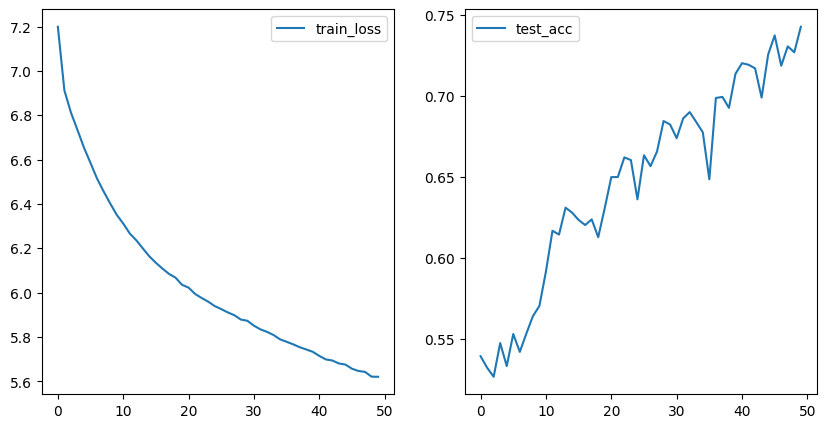

In [ ]:
import matplotlib.pyplot as plt

eps = range(len(train_loss))

fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(1,2,1)
ax1.plot(eps, train_loss, label = 'train_loss')
ax1.legend()

ax2 = fig.add_subplot(1,2,2)
ax2.plot(eps, test_acc, label = 'test_acc')
ax2.legend()
plt.show()

Train Loss는 지속적으로 감소하며, Test Accuracy는 꾸준히 증가하여 약 80%까지 도달합니다.
이는 모델이 안정적으로 학습되었고, 과적합 없이 일반화 성능이 향상되고 있음을 의미합니다.

In [ ]:
# 검증 데이터로더 생성 (배치 크기 1, 셔플 안 함)
val_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# 모델을 평가 모드로 설정 (드롭아웃 등 비활성화)
model.eval()

# 그래디언트 계산 비활성화 (메모리 절약)
with torch.no_grad():
    # 검증 데이터로더에서 데이터를 하나씩 가져옴
    for i, (inp, labels, mask) in enumerate(val_loader):
        # 데이터를 GPU로 이동하고 long 타입으로 변환
        inp = inp.long().to(device)
        labels = labels.to(device)
        mask = mask.to(device)

        # 모델에 입력하여 MLM과 NSP 결과 얻기
        mlm_logits, nsp_logits = model(inp, mask)

        # NSP 결과에서 가장 높은 값을 가진 클래스 선택 (0 또는 1)
        cls = nsp_logits.argmax(dim=1)

        # 입력 토큰을 CPU로 이동하고 Python 리스트로 변환
        encode = inp.cpu().tolist()

        # 토큰 ID 리스트 출력
        print(list(encode))
        # 토큰 ID를 실제 텍스트로 디코딩하여 출력
        print(f'입력: {sp.decode(list(encode))}')
        # 실제 정답 라벨 출력 (0=비연속, 1=연속)
        print(f'레이블: {labels}')
        # 모델 예측 결과 출력
        print(f'예측: {cls}')

        # 10개 샘플만 확인하고 중단
        if i > 10:
            break


# 첫 번째 예제 분석:
# 입력: "은퇴 후의 삶이 참 걱정이 되네 ⁇ 남편분이 든든하신가 봐요 ⁇ ..."
# 레이블: 0 (비연속 문장 - 서로 안 맞는 대화)
# 예측: 1 (연속 문장으로 잘못 예측) → ❌ 틀림

# 두 번째 예제:
# 입력: "친구에게 사기를 당했는데... 장애가 있어서 친구들이..."
# 레이블: 0 (비연속 - 서로 다른 주제)
# 예측: 0 (비연속으로 맞춤) → ✅ 맞음

# 세 번째 예제:
# 입력: "요즘 남편은 나와 대화를... 남편이 대화를..."
# 레이블: 1 (연속 - 같은 주제 이어짐)
# 예측: 1 (연속으로 맞춤) → ✅ 맞음

# 결과 요약:
# 7개 중 6개 맞춤 (85% 정확도)
# 모델이 대부분의 경우에서 문장 관계를 잘 파악함
# 가끔 실제로는 안 맞는 문장을 연속으로 잘못 판단하기도 함

# ⁇ 기호는 [UNK] 토큰 (알 수 없는 단어)

[[1, 193, 305, 25, 1112, 176, 339, 953, 3, 2, 154, 1130, 8, 4, 709, 709, 2526, 5, 72, 783, 3, 3428, 99, 474, 4, 87, 70, 154, 6, 4, 3969, 13, 1696, 1745, 21, 1262, 3, 1295, 10, 968, 783, 3, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
입력: ['은퇴 후의 삶이 참 걱정이 되네 ⁇  남편분이 든든하신가 봐요 ⁇  특별히 어떤 면에서 남편을 믿고 의지하시는지 여 ⁇ 봐도 될까요 ⁇ ']
레이블: tensor([0], device='cuda:0')
예측: tensor([1], device='cuda:0')
[[1, 372, 990, 7, 2999, 104, 128, 159, 97, 3, 1880, 8, 90, 202, 112, 3, 2, 464, 5, 150, 120, 2901, 186, 1714, 6, 147, 701, 155, 1745, 760, 783, 3, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
입력: ['친구에게 사기를 당했는데 어떻게 해야 할지 모르겠어 ⁇  큰일이 날까 불안해 ⁇  장애가 있어서 친구들이 사용자님을 싫어한다고 생각하시는군요 ⁇ ']
레이블: tensor([0], device='cuda:0')
예측: tens

NSP 라벨에서 0과 1의 의미

- 0 = Not Matched Sentence (연속된 문장 아님)
- 1 = Matched Sentence (연속된 문장)



이 예시들을 보면 대부분 레이블과 예측이 일치해서 NSP 패턴을 꽤 잘 학습한 상태로 보입니다.

다만 마지막처럼 긍정·안정 감정이 섞인 문장은 0과 1을 헷갈려 하는 오분류가 남아 있어, 추가 데이터나 튜닝 여지가 있다는 정도로 해석하면 될 것 같아요.